In [ ]:
# Cell 0: Import all required libraries
import numpy as np
import pandas as pd
import h5py
import tensorflow as tf
from tensorflow import keras
import json
import os
from datetime import datetime
import matplotlib.pyplot as plt

print("All libraries imported")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


All libraries imported
TensorFlow version: 2.19.0
GPU available: True


In [ ]:
BASE_DIR = "/content"
DATA_DIR = "/content/data"

# Check if files exist
input_path = os.path.join(DATA_DIR, "X_train.h5")
y_path = os.path.join(DATA_DIR, "y_train_tX9Br0C.csv")
meta_path = os.path.join(DATA_DIR, "X_train_h7ipJUo.csv")

print("=== FILE CHECK ===")
print(f"X_train.h5 exists: {os.path.exists(input_path)}")
print(f"y_train CSV exists: {os.path.exists(y_path)}")
print(f"Metadata CSV exists: {os.path.exists(meta_path)}")

if not all([os.path.exists(input_path), os.path.exists(y_path), os.path.exists(meta_path)]):
    print("\n Please upload the files using the Files panel on the left!")
    print("Required files:")
    print("  1. X_train.h5")
    print("  2. y_train_tX9Br0C.csv")
    print("  3. X_train_h7ipJUo.csv")
else:
    print("\n✓ All files found!")

=== FILE CHECK ===
X_train.h5 exists: True
y_train CSV exists: True
Metadata CSV exists: True

✓ All files found!


In [ ]:
# Mount Google Drive and copy files
from google.colab import drive
import os
import shutil

# Mount Drive
drive.mount('/content/drive', force_remount=True)

# Source and destination
DRIVE_DIR = "/content/drive/MyDrive/Sleep_Apnea_Data"
LOCAL_DIR = "/content/data"
os.makedirs(LOCAL_DIR, exist_ok=True)

files_to_copy = [
    "X_train.h5",
    "y_train_tX9Br0C.csv",
    "X_train_h7ipJUo.csv"
]

print("Copying files from Google Drive to Colab...")
for filename in files_to_copy:
    source = os.path.join(DRIVE_DIR, filename)
    dest = os.path.join(LOCAL_DIR, filename)

    if os.path.exists(source):
        print(f"\nCopying {filename}...")
        shutil.copy2(source, dest)
        size_mb = os.path.getsize(dest) / (1024**2)
        print(f"✓ Done! Size: {size_mb:.2f} MB")
    else:
        print(f" {filename} not found in Google Drive!")

# Verify H5 file
import h5py
h5_path = os.path.join(LOCAL_DIR, "X_train.h5")
if os.path.exists(h5_path):
    try:
        with h5py.File(h5_path, "r") as f:
            print(f"\n H5 file is valid! Shape: {f['data'].shape}")
    except Exception as e:
        print(f"\n H5 file corrupted: {e}")
else:
    print("\n X_train.h5 not found!")


Mounted at /content/drive
Copying files from Google Drive to Colab...

Copying X_train.h5...
✓ Done! Size: 1871.07 MB

Copying y_train_tX9Br0C.csv...
✓ Done! Size: 0.78 MB

Copying X_train_h7ipJUo.csv...
✓ Done! Size: 0.05 MB

 H5 file is valid! Shape: (4400, 72002)


In [ ]:
# Cell 3: Load and Reshape Data
import pandas as pd
import numpy as np
import h5py

print("Loading input data...")
input_path = "/content/data/X_train.h5"
print("Loading input data...")
input_path = "/content/data/X_train.h5"
y_path = "/content/data/y_train_tX9Br0C.csv"
meta_path = "/content/data/X_train_h7ipJUo.csv"

with h5py.File(input_path, "r") as f:
    raw_data = f["data"][:]

print(f"Raw data shape: {raw_data.shape}")

# Extract and reshape
window_ids = raw_data[:, 0].astype(int)
subject_ids_from_h5 = raw_data[:, 1].astype(int)
X_flat = raw_data[:, 2:].astype("float32")

SAMPLES_PER_WIN = 9000
N_CH = 8
X = X_flat.reshape(len(X_flat), SAMPLES_PER_WIN, N_CH)
print(f"X reshaped: {X.shape}")

# Load metadata
meta = pd.read_csv(meta_path)
subject_ids = meta["Subject_ID"].to_numpy()
print(f"Unique subjects: {len(np.unique(subject_ids))}")

# Load labels
y_df = pd.read_csv(y_path)
y_id = y_df["ID"].to_numpy()
mask_cols = [c for c in y_df.columns if c.startswith("y_")]
y = y_df[mask_cols].to_numpy().astype("float32")
print(f"y shape: {y.shape}")

print("\n=== DATA SUMMARY ===")
print(f"Total windows: {X.shape[0]}")
print(f"Samples per window: {X.shape[1]} (90 seconds at 100 Hz)")
print(f"Channels: {X.shape[2]}")
print(f"Positive label ratio: {y.mean():.2%}")


Loading input data...
Loading input data...
Raw data shape: (4400, 72002)
X reshaped: (4400, 9000, 8)
Unique subjects: 22
y shape: (4400, 90)

=== DATA SUMMARY ===
Total windows: 4400
Samples per window: 9000 (90 seconds at 100 Hz)
Channels: 8
Positive label ratio: 6.87%


In [ ]:
# Cell 4: Train/Val Split
def train_val_split_by_subject(X, y, subject_ids, train_ratio=0.7, seed=42):
    rng = np.random.default_rng(seed)
    unique_subj = np.unique(subject_ids)
    rng.shuffle(unique_subj)
    n_train = int(len(unique_subj) * train_ratio)
    train_subj = unique_subj[:n_train]
    train_mask = np.isin(subject_ids, train_subj)
    val_mask = ~train_mask
    return X[train_mask], X[val_mask], y[train_mask], y[val_mask], train_subj

X_train, X_val, y_train, y_val, train_subjects = train_val_split_by_subject(
    X, y, subject_ids, train_ratio=0.7, seed=42
)

print("=== TRAIN/VAL SPLIT ===")
print(f"Total subjects: {len(np.unique(subject_ids))}")
print(f"Train subjects: {len(train_subjects)}")
print(f"Val subjects: {len(np.unique(subject_ids)) - len(train_subjects)}")
print(f"\nTrain X: {X_train.shape}, Train y: {y_train.shape}")
print(f"Val X: {X_val.shape}, Val y: {y_val.shape}")
print(f"\nTrain positive: {y_train.mean():.2%}")
print(f"Val positive: {y_val.mean():.2%}")


=== TRAIN/VAL SPLIT ===
Total subjects: 22
Train subjects: 15
Val subjects: 7

Train X: (3000, 9000, 8), Train y: (3000, 90)
Val X: (1400, 9000, 8), Val y: (1400, 90)

Train positive: 6.20%
Val positive: 8.30%


In [ ]:
# Cell 5: Build LSTM Model
def build_lstm_small(input_shape=(9000, 8)):
    inputs = keras.Input(shape=input_shape, name='input')

    x = keras.layers.Bidirectional(
        keras.layers.LSTM(128, return_sequences=True), name='bilstm_1'
    )(inputs)
    x = keras.layers.Dropout(0.3, name='dropout_1')(x)

    x = keras.layers.Bidirectional(
        keras.layers.LSTM(64, return_sequences=True), name='bilstm_2'
    )(x)
    x = keras.layers.Dropout(0.3, name='dropout_2')(x)

    x = keras.layers.Bidirectional(
        keras.layers.LSTM(32, return_sequences=True), name='bilstm_3'
    )(x)
    x = keras.layers.Dropout(0.3, name='dropout_3')(x)

    x = keras.layers.AveragePooling1D(pool_size=100, name='pool')(x)

    outputs = keras.layers.TimeDistributed(
        keras.layers.Dense(1, activation='sigmoid'), name='output_dense'
    )(x)
    outputs = keras.layers.Reshape((90,), name='output_reshape')(outputs)

    model = keras.Model(inputs=inputs, outputs=outputs, name="lstm_small")
    return model

print("=== BUILDING LSTM MODEL ===")
model = build_lstm_small()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTotal parameters: {model.count_params():,}")


=== BUILDING LSTM MODEL ===


Model: "lstm_small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 9000, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 9000, 256)      │       140,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9000, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 9000, 128)      │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_3 (Bidirectional)        │ (None, 9000, 64)       │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool (AveragePooling1D)         │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 90, 1)          │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_reshape (Reshape)        │ (None, 90)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345,921 (1.32 MB)

 Trainable params: 345,921 (1.32 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 345,921


In [ ]:
# Cell 6 & 7: Setup callbacks and train
MODEL_NAME = "lstm_small"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        f"/content/{MODEL_NAME}_best.keras",
        save_best_only=True, monitor='val_loss', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
    )
]

print("=" * 60)
print("TRAINING LSTM MODEL ON GPU")
print("=" * 60)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Batch size: 16")
print(f"Max epochs: 10")
print("=" * 60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print(f"TRAINING COMPLETE!")
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)

# Save final model
model.save(f"/content/{MODEL_NAME}_final.keras")

# Print final metrics
print("\n=== FINAL METRICS ===")
print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best val loss: {min(history.history['val_loss']):.4f}")
print(f"Best val accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Final train loss: {history.history['loss'][-1]:.4f}")
print(f"Final train accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final val loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final val accuracy: {history.history['val_accuracy'][-1]:.4f}")


TRAINING LSTM MODEL ON GPU
Start time: 2026-01-04 21:20:37
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Batch size: 16
Max epochs: 10
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0081 - loss: 0.2748
Epoch 1: val_loss improved from inf to 0.29571, saving model to /content/lstm_small_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.0081 - loss: 0.2746 - val_accuracy: 0.0114 - val_loss: 0.2957 - learning_rate: 0.0010
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0044 - loss: 0.2352
Epoch 2: val_loss improved from 0.29571 to 0.28603, saving model to /content/lstm_small_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.0044 - loss: 0.2352 - val_accuracy: 0.0021 - val_loss: 0.2860 - learning_rate: 0.0010
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0059 - loss: 0.2253
Epoch 3: val_loss did not improve from 0.28603
188/188 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.005

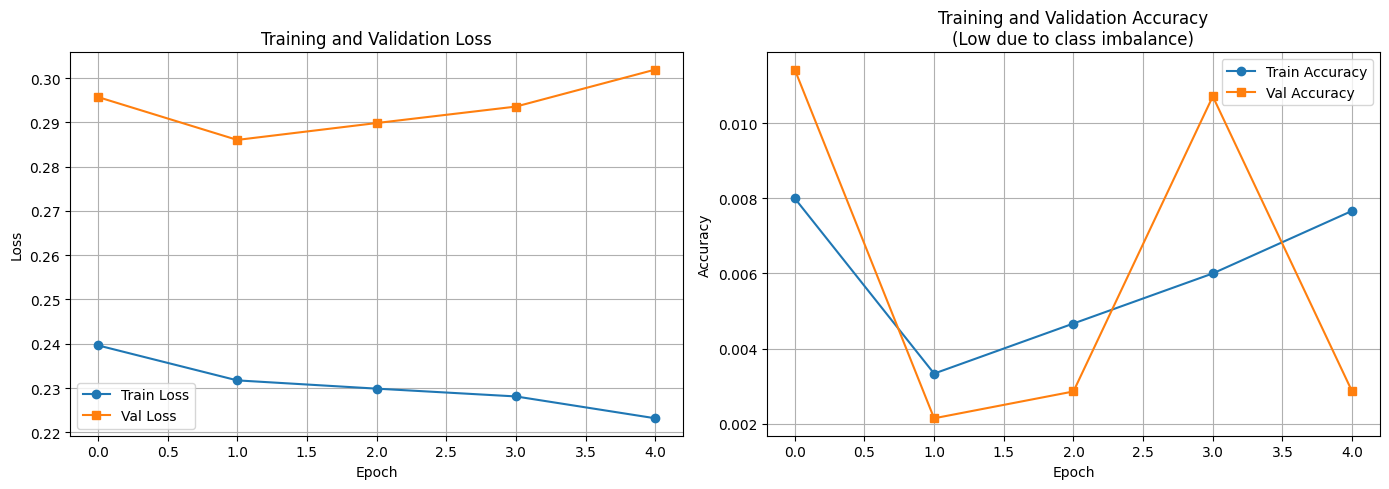

✓ Training curves saved
✓ Training history saved to JSON
✓ Model config saved

TRAINING SUMMARY
Model: LSTM-small (345,921 parameters)
Training time: ~25 minutes on GPU
Epochs: 5 (early stopping)
Best validation loss: 0.2860

Note: Low accuracy (~1%) is expected due to severe class
imbalance (only 6.87% positive samples). The official metric
is event-based F1 score, not point-wise accuracy.


In [ ]:
# Cell 8: Visualize training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], marker='o', label='Train Loss')
axes[0].plot(history.history['val_loss'], marker='s', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy (note: low due to class imbalance)
axes[1].plot(history.history['accuracy'], marker='o', label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], marker='s', label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy\n(Low due to class imbalance)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved")

# Save training history
history_dict = {key: [float(val) for val in values]
                for key, values in history.history.items()}

with open('/content/lstm_small_history.json', 'w') as f:
    json.dump(history_dict, f, indent=2)

print("✓ Training history saved to JSON")

# Model summary for documentation
config = {
    "model_name": "lstm_small",
    "architecture": "3-layer Bidirectional LSTM",
    "input_shape": [9000, 8],
    "output_shape": [90],
    "total_parameters": 345921,
    "batch_size": 16,
    "epochs_trained": len(history.history['loss']),
    "best_val_loss": float(min(history.history['val_loss'])),
    "best_val_accuracy": float(max(history.history['val_accuracy'])),
    "learning_rate_initial": 0.001,
    "optimizer": "Adam",
    "loss": "binary_crossentropy",
    "training_time": "~25 minutes",
    "gpu": "T4"
}

with open('/content/lstm_small_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✓ Model config saved")
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Model: LSTM-small (345,921 parameters)")
print(f"Training time: ~25 minutes on GPU")
print(f"Epochs: {len(history.history['loss'])} (early stopping)")
print(f"Best validation loss: {min(history.history['val_loss']):.4f}")
print(f"\nNote: Low accuracy (~1%) is expected due to severe class")
print(f"imbalance (only 6.87% positive samples). The official metric")
print(f"is event-based F1 score, not point-wise accuracy.")
print("="*60)


In [ ]:
# Cell 9: Download trained models and results
from google.colab import files
import shutil
import zipfile

# Create a zip file with all results
zip_filename = '/content/lstm_results.zip'

files_to_zip = [
    '/content/lstm_small_final.keras',
    '/content/lstm_small_best.keras',
    '/content/lstm_small_history.json',
    '/content/lstm_small_config.json',
    '/content/lstm_training_curves.png'
]

print("Creating results package...")
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file, os.path.basename(file))
            print(f"  ✓ Added {os.path.basename(file)}")

print(f"\n✓ Results packaged: {os.path.getsize(zip_filename) / (1024**2):.2f} MB")

# Download the zip file
print("\nDownloading results...")
files.download(zip_filename)

print("\n" + "="*60)
print(" LSTM MODEL TRAINING COMPLETE!")
print("="*60)
print("\nDownloaded files:")
print("  • lstm_small_final.keras - Final trained model")
print("  • lstm_small_best.keras - Best checkpoint")
print("  • lstm_small_history.json - Training history")
print("  • lstm_small_config.json - Model configuration")
print("  • lstm_training_curves.png - Training visualization")
print("\n" + "="*60)


Creating results package...
  ✓ Added lstm_small_final.keras
  ✓ Added lstm_small_best.keras
  ✓ Added lstm_small_history.json
  ✓ Added lstm_small_config.json
  ✓ Added lstm_training_curves.png

✓ Results packaged: 8.21 MB



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 LSTM MODEL TRAINING COMPLETE!

Downloaded files:
  • lstm_small_final.keras - Final trained model
  • lstm_small_best.keras - Best checkpoint
  • lstm_small_history.json - Training history
  • lstm_small_config.json - Model configuration
  • lstm_training_curves.png - Training visualization

